In [ ]:
# ============================================
# Tattoo Feature Extractor (Demo)
# Salida estructurada para usar después con LLM
# ============================================

import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# -----------------------------
# Paths
# -----------------------------
BASE = "/content/drive/MyDrive/HDA-IWBF-2023/synthetic-tattoo-images"
IMAGE_PATH = os.path.join(BASE, "JPGImages")
MASK_PATH  = os.path.join(BASE, "SegmentationClass")

In [ ]:
# Para guardar JSON
SAVE_JSON = True
JSON_OUT_DIR = os.path.join(BASE, "debug_feature_json")
os.makedirs(JSON_OUT_DIR, exist_ok=True)

In [ ]:
# -----------------------------
# IO helpers
# -----------------------------
def read_image(path: str) -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {path}")
    return img

def read_mask(path: str) -> np.ndarray:
    m = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if m is None:
        raise FileNotFoundError(f"No se pudo leer la máscara: {path}")
    if len(m.shape) == 3:
        m = m[:, :, 0]
    return m

def list_pairs(image_dir: str, mask_dir: str):
    imgs = sorted([
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    pairs = []
    for f in imgs:
        base = os.path.splitext(f)[0]
        candidates = [base + ".png", base + ".jpg", base + ".jpeg"]

        mpath = None
        for cand in candidates:
            p = os.path.join(mask_dir, cand)
            if os.path.exists(p):
                mpath = p
                break

        if mpath is not None:
            pairs.append((os.path.join(image_dir, f), mpath))

    return pairs

def safe_div(a, b):
    return float(a) / float(b) if b != 0 else 0.0

def to_python_scalar(x):
    if isinstance(x, (np.floating,)):
        return float(x)
    if isinstance(x, (np.integer,)):
        return int(x)
    return x

In [ ]:
# -----------------------------
# FUNCIÓN DE POSICIÓN
# -----------------------------
def get_position_label(cx: float, cy: float) -> str:
    # Horizontal
    if cx < 0.33:
        horiz = "left"
    elif cx > 0.66:
        horiz = "right"
    else:
        horiz = "center"

    # Vertical
    if cy < 0.33:
        vert = "top"
    elif cy > 0.66:
        vert = "bottom"
    else:
        vert = "center"

    if vert == "center" and horiz == "center":
        return "center"
    elif vert == "center":
        return f"center-{horiz}"
    elif horiz == "center":
        return f"{vert}-center"
    else:
        return f"{vert}-{horiz}"

In [ ]:
# -----------------------------
# Mask parsing
# -----------------------------
def mask_to_regions(mask: np.ndarray):
    if len(mask.shape) == 3:
        mask = mask[:, :, 0]

    background = (mask <= 30).astype(np.uint8)
    skin       = (mask >= 220).astype(np.uint8)
    tattoo     = ((mask > 30) & (mask < 220)).astype(np.uint8)

    return tattoo, skin, background

In [ ]:
# -----------------------------
# Geometry helpers
# -----------------------------
def bbox_from_mask(bin_mask: np.ndarray):
    ys, xs = np.where(bin_mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None
    return int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())

def expand_bbox(bbox, img_shape, margin_ratio=0.08):
    if bbox is None:
        return None

    x0, y0, x1, y1 = bbox
    h, w = img_shape[:2]

    bw = x1 - x0 + 1
    bh = y1 - y0 + 1

    mx = int(bw * margin_ratio)
    my = int(bh * margin_ratio)

    x0e = max(0, x0 - mx)
    y0e = max(0, y0 - my)
    x1e = min(w - 1, x1 + mx)
    y1e = min(h - 1, y1 + my)

    return x0e, y0e, x1e, y1e

def crop_from_bbox(img: np.ndarray, bbox):
    if bbox is None:
        return None
    x0, y0, x1, y1 = bbox
    return img[y0:y1+1, x0:x1+1].copy()

In [ ]:
# -----------------------------
# Connected components
# -----------------------------
def connected_components(mask_bin: np.ndarray):
    nlabels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_bin, connectivity=8)
    return nlabels, labels, stats, centroids

def remove_small_components(mask_bin: np.ndarray, min_area_ratio=0.01, min_area_px=30):
    total_area = int(mask_bin.sum())
    if total_area == 0:
        return mask_bin.copy()

    nlabels, labels, stats, _ = connected_components(mask_bin)
    thr = max(min_area_px, int(total_area * min_area_ratio))

    out = np.zeros_like(mask_bin, dtype=np.uint8)
    for i in range(1, nlabels):
        area = int(stats[i, cv2.CC_STAT_AREA])
        if area >= thr:
            out[labels == i] = 1
    return out

def count_large_components(mask_bin: np.ndarray, min_area_ratio=0.02, min_area_px=30):
    total_area = int(mask_bin.sum())
    if total_area == 0:
        return 0

    nlabels, labels, stats, _ = connected_components(mask_bin)
    thr = max(min_area_px, int(total_area * min_area_ratio))

    count = 0
    for i in range(1, nlabels):
        area = int(stats[i, cv2.CC_STAT_AREA])
        if area >= thr:
            count += 1
    return count

In [ ]:
# -----------------------------
# Visualization
# -----------------------------
def overlay_contour(img_bgr: np.ndarray, mask_bin: np.ndarray, bbox=None):
    out = img_bgr.copy()
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cv2.drawContours(out, contours, -1, (0, 255, 0), 2)

    if bbox is not None:
        x0, y0, x1, y1 = bbox
        cv2.rectangle(out, (x0, y0), (x1, y1), (255, 0, 0), 2)

    return out

def component_overlay(mask_bin: np.ndarray, min_area_ratio=0.02, min_area_px=30):
    h, w = mask_bin.shape
    vis = np.zeros((h, w, 3), dtype=np.uint8)

    total_area = int(mask_bin.sum())
    if total_area == 0:
        return vis

    nlabels, labels, stats, _ = connected_components(mask_bin)
    thr = max(min_area_px, int(total_area * min_area_ratio))

    palette = [
        (255, 0, 0),
        (0, 255, 0),
        (0, 0, 255),
        (255, 255, 0),
        (255, 0, 255),
        (0, 255, 255),
        (255, 128, 0),
        (128, 0, 255),
    ]

    color_idx = 0
    for i in range(1, nlabels):
        area = int(stats[i, cv2.CC_STAT_AREA])
        if area >= thr:
            vis[labels == i] = palette[color_idx % len(palette)]
            color_idx += 1

    return vis

In [ ]:
# -----------------------------
# Feature extraction
# -----------------------------
def extract_features_structured(img_bgr: np.ndarray, mask_gray: np.ndarray, filename: str):
    raw_tattoo, skin, background = mask_to_regions(mask_gray)
    clean_tattoo = remove_small_components(raw_tattoo, min_area_ratio=0.01, min_area_px=30)

    h, w = mask_gray.shape[:2]
    tattoo_area = int(clean_tattoo.sum())
    skin_area = int(skin.sum())

    bbox = bbox_from_mask(clean_tattoo)
    bbox_exp = expand_bbox(bbox, img_bgr.shape, margin_ratio=0.08) if bbox is not None else None
    crop_img = crop_from_bbox(img_bgr, bbox_exp) if bbox_exp is not None else None

    result = {
        "metadata": {
            "filename": filename,
            "image_height": h,
            "image_width": w,
        },
        "spatial_features": {},
        "shape_features": {},
        "appearance_features": {},
    }

    if tattoo_area == 0:
        result["spatial_features"] = {
            "tattoo_area_px": 0,
            "skin_area_px": int(skin_area),
            "tattoo_area_frac_img": 0.0,
            "tattoo_over_skin_frac": 0.0,
            "bbox": None,
            "bbox_aspect_ratio": 0.0,
            "position": {
                "x_norm": -1.0,
                "y_norm": -1.0,
                "label": "none"
            }
        }
        result["shape_features"] = {
            "num_components_raw": 0,
            "num_components_large": 0,
            "perimeter": 0.0,
            "circularity": 0.0,
            "solidity": 0.0,
            "ellipse_major_axis": 0.0,
            "ellipse_minor_axis": 0.0,
            "elongation": 0.0,
            "orientation_deg": 0.0,
        }
        result["appearance_features"] = {
            "tattoo_gray_mean": None,
            "tattoo_gray_std": None,
            "skin_gray_mean": None,
            "skin_gray_std": None,
            "contrast_skin_minus_tattoo": None,
            "cohens_d": None,
            "crop_gray_mean": None,
            "crop_gray_std": None,
            "edge_density_crop": None,
            "entropy_crop": None,
        }
        return result, clean_tattoo, crop_img

    ys, xs = np.where(clean_tattoo > 0)
    x0, x1 = int(xs.min()), int(xs.max())
    y0, y1 = int(ys.min()), int(ys.max())
    bw, bh = (x1 - x0 + 1), (y1 - y0 + 1)

    cx = float(xs.mean()) / w
    cy = float(ys.mean()) / h
    position_label = get_position_label(cx, cy)

    result["spatial_features"] = {
        "tattoo_area_px": int(tattoo_area),
        "skin_area_px": int(skin_area),
        "tattoo_area_frac_img": safe_div(tattoo_area, h * w),
        "tattoo_over_skin_frac": safe_div(tattoo_area, skin_area),
        "bbox": {
            "x": int(x0),
            "y": int(y0),
            "w": int(bw),
            "h": int(bh),
        },
        "bbox_aspect_ratio": safe_div(bw, bh),
        "position": {
            "x_norm": cx,
            "y_norm": cy,
            "label": position_label
        }
    }

    nlabels, labels, stats, _ = connected_components(clean_tattoo)
    num_components_raw = int(nlabels - 1)
    num_components_large = int(count_large_components(clean_tattoo, min_area_ratio=0.02, min_area_px=30))

    contours, _ = cv2.findContours(clean_tattoo, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    perimeter = 0.0
    circularity = 0.0
    solidity = 0.0
    ellipse_major = 0.0
    ellipse_minor = 0.0
    elongation = 0.0
    orientation_deg = 0.0

    if contours:
        cnt = max(contours, key=cv2.contourArea)
        area = float(cv2.contourArea(cnt))
        perimeter = float(cv2.arcLength(cnt, True))
        circularity = safe_div(4 * np.pi * area, perimeter * perimeter)

        hull = cv2.convexHull(cnt)
        hull_area = float(cv2.contourArea(hull))
        solidity = safe_div(area, hull_area)

        if len(cnt) >= 5:
            (_, _), (MA, ma), angle = cv2.fitEllipse(cnt)
            ellipse_major = float(max(MA, ma))
            ellipse_minor = float(min(MA, ma))
            elongation = safe_div(max(MA, ma), min(MA, ma))
            orientation_deg = float(angle)

    result["shape_features"] = {
        "num_components_raw": num_components_raw,
        "num_components_large": num_components_large,
        "perimeter": perimeter,
        "circularity": circularity,
        "solidity": solidity,
        "ellipse_major_axis": ellipse_major,
        "ellipse_minor_axis": ellipse_minor,
        "elongation": elongation,
        "orientation_deg": orientation_deg,
    }

    gray_full = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    tattoo_pixels = gray_full[clean_tattoo > 0]
    skin_pixels = gray_full[skin > 0] if skin.sum() > 0 else None

    tattoo_gray_mean = float(tattoo_pixels.mean())
    tattoo_gray_std = float(tattoo_pixels.std())

    skin_gray_mean = None
    skin_gray_std = None
    contrast_skin_minus_tattoo = None
    cohens_d = None

    if skin_pixels is not None and len(skin_pixels) > 50:
        skin_gray_mean = float(skin_pixels.mean())
        skin_gray_std = float(skin_pixels.std())
        diff = skin_gray_mean - tattoo_gray_mean
        pooled = np.sqrt((skin_gray_std**2 + tattoo_gray_std**2) / 2.0)
        contrast_skin_minus_tattoo = float(diff)
        cohens_d = safe_div(diff, pooled)

    crop_gray_mean = None
    crop_gray_std = None
    edge_density_crop = None
    entropy_crop = None

    if crop_img is not None:
        gray_crop = cv2.cvtColor(crop_img, cv2.COLOR_BGR2GRAY)
        crop_gray_mean = float(gray_crop.mean())
        crop_gray_std = float(gray_crop.std())

        edges_crop = cv2.Canny(gray_crop, 80, 160)
        edge_density_crop = float(edges_crop.mean() / 255.0)

        hist = cv2.calcHist([gray_crop], [0], None, [256], [0, 256]).ravel()
        p = hist / (hist.sum() + 1e-9)
        entropy_crop = float(-np.sum(p[p > 0] * np.log2(p[p > 0])))

    result["appearance_features"] = {
        "tattoo_gray_mean": tattoo_gray_mean,
        "tattoo_gray_std": tattoo_gray_std,
        "skin_gray_mean": skin_gray_mean,
        "skin_gray_std": skin_gray_std,
        "contrast_skin_minus_tattoo": contrast_skin_minus_tattoo,
        "cohens_d": cohens_d,
        "crop_gray_mean": crop_gray_mean,
        "crop_gray_std": crop_gray_std,
        "edge_density_crop": edge_density_crop,
        "entropy_crop": entropy_crop,
    }

    return result, clean_tattoo, crop_img

In [ ]:
# -----------------------------
# Pretty JSON helpers
# -----------------------------
def sanitize_for_json(obj):
    if isinstance(obj, dict):
        return {k: sanitize_for_json(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [sanitize_for_json(v) for v in obj]
    if isinstance(obj, tuple):
        return [sanitize_for_json(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    return obj

In [ ]:
# -----------------------------
# Display
# -----------------------------
def show_debug_example(ipath, mpath):
    img = read_image(ipath)
    mask = read_mask(mpath)

    filename = os.path.basename(ipath)
    features, clean_tattoo, crop_img = extract_features_structured(img, mask, filename)

    bbox = bbox_from_mask(clean_tattoo)
    bbox_exp = expand_bbox(bbox, img.shape, margin_ratio=0.08) if bbox is not None else None
    overlay = overlay_contour(img, clean_tattoo, bbox_exp)
    comp_vis = component_overlay(clean_tattoo, min_area_ratio=0.02, min_area_px=30)

    fig = plt.figure(figsize=(18, 10))

    ax1 = plt.subplot(2, 4, 1)
    ax1.set_title(f"Original\n{filename}")
    ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax1.axis("off")

    ax2 = plt.subplot(2, 4, 2)
    ax2.set_title("Raw mask")
    ax2.imshow(mask, cmap="gray")
    ax2.axis("off")

    ax3 = plt.subplot(2, 4, 3)
    ax3.set_title("Clean tattoo mask")
    ax3.imshow(clean_tattoo, cmap="gray")
    ax3.axis("off")

    ax4 = plt.subplot(2, 4, 4)
    ax4.set_title("Overlay + bbox")
    ax4.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax4.axis("off")

    ax5 = plt.subplot(2, 4, 5)
    ax5.set_title("Tattoo crop")
    if crop_img is not None:
        ax5.imshow(cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB))
    ax5.axis("off")

    ax6 = plt.subplot(2, 4, 6)
    ax6.set_title("Large components")
    ax6.imshow(comp_vis)
    ax6.axis("off")

    ax7 = plt.subplot(2, 4, 7)
    ax7.set_title("Structured features")
    pretty_json = json.dumps(sanitize_for_json(features), indent=2, ensure_ascii=False)
    ax7.text(
        0.01, 0.99,
        pretty_json[:4000],
        va="top",
        ha="left",
        fontsize=8,
        family="monospace"
    )
    ax7.axis("off")

    ax8 = plt.subplot(2, 4, 8)
    ax8.set_title("Feature blocks")
    summary_text = (
        "Blocks for LLM:\n\n"
        "- metadata\n"
        "- spatial_features\n"
        "- shape_features\n"
        "- appearance_features\n\n"
        "Recommended later input:\n"
        "1. crop image\n"
        "2. structured JSON\n"
        "3. forensic instruction prompt"
    )
    ax8.text(0.01, 0.99, summary_text, va="top", ha="left", fontsize=10, family="monospace")
    ax8.axis("off")

    plt.tight_layout()
    plt.show()

    return features

Total pairs: 5500
Selected image: 01_14_1.37_2593.jpg


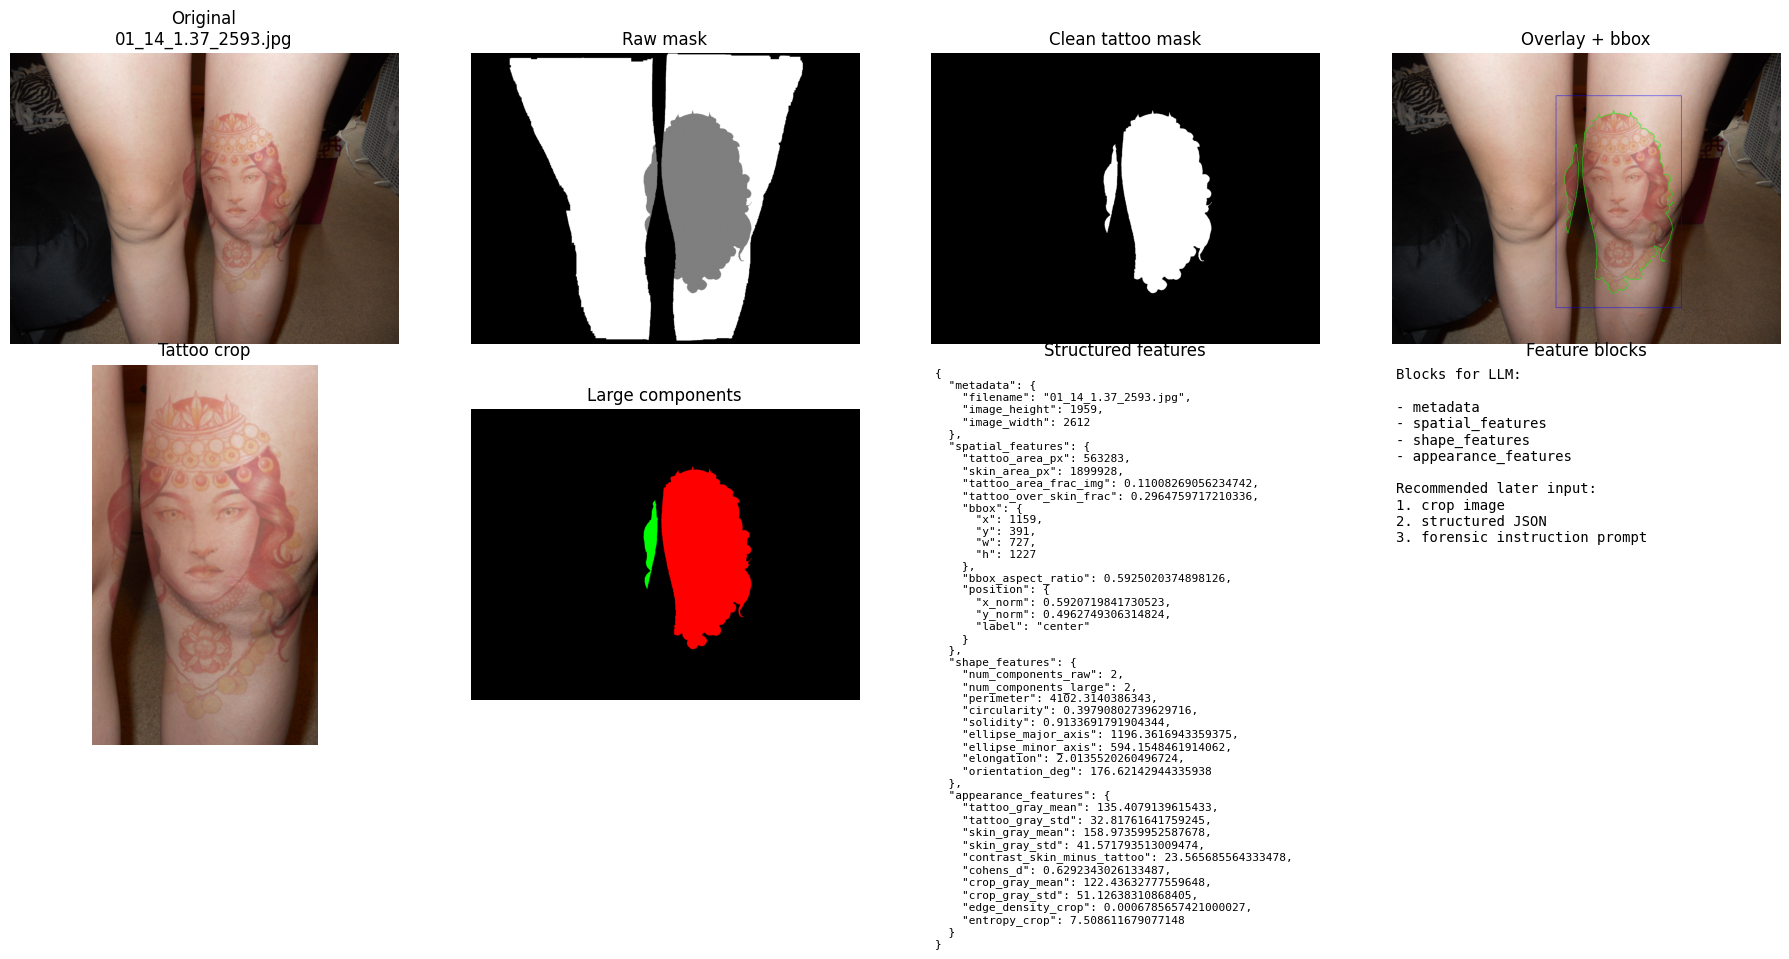

In [ ]:
# -----------------------------
# Run one example only
# -----------------------------
pairs = list_pairs(IMAGE_PATH, MASK_PATH)
print("Total pairs:", len(pairs))

if not pairs:
    raise RuntimeError("No encontré pares imagen-máscara. Revisa las rutas.")

INDEX = 0   # <-- ejemplo

if INDEX < 0 or INDEX >= len(pairs):
    raise IndexError(f"INDEX fuera de rango. Debe estar entre 0 y {len(pairs)-1}")

ipath, mpath = pairs[INDEX]
print("Selected image:", os.path.basename(ipath))

features = show_debug_example(ipath, mpath)

In [ ]:
# -----------------------------
# Print structured result
# -----------------------------
features_clean = sanitize_for_json(features)

print("\n================ STRUCTURED FEATURES ================\n")
print(json.dumps(features_clean, indent=2, ensure_ascii=False))


================ STRUCTURED FEATURES ================

{
  "metadata": {
    "filename": "01_14_1.37_2593.jpg",
    "image_height": 1959,
    "image_width": 2612
  },
  "spatial_features": {
    "tattoo_area_px": 563283,
    "skin_area_px": 1899928,
    "tattoo_area_frac_img": 0.11008269056234742,
    "tattoo_over_skin_frac": 0.2964759717210336,
    "bbox": {
      "x": 1159,
      "y": 391,
      "w": 727,
      "h": 1227
    },
    "bbox_aspect_ratio": 0.5925020374898126,
    "position": {
      "x_norm": 0.5920719841730523,
      "y_norm": 0.4962749306314824,
      "label": "center"
    }
  },
  "shape_features": {
    "num_components_raw": 2,
    "num_components_large": 2,
    "perimeter": 4102.3140386343,
    "circularity": 0.39790802739629716,
    "solidity": 0.9133691791904344,
    "ellipse_major_axis": 1196.3616943359375,
    "ellipse_minor_axis": 594.1548461914062,
    "elongation": 2.0135520260496724,
    "orientation_deg": 176.62142944335938
  },
  "appearance_features": {


In [ ]:
# ------------------
# JSON save
# ------------------
if SAVE_JSON:
    base = os.path.splitext(os.path.basename(ipath))[0]
    out_json = os.path.join(JSON_OUT_DIR, f"{base}.json")
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(features_clean, f, indent=2, ensure_ascii=False)
    print("\nJSON guardado en:", out_json)


JSON guardado en: /content/drive/MyDrive/HDA-IWBF-2023/synthetic-tattoo-images/debug_feature_json/01_14_1.37_2593.json
